In [ ]:
# IMPORT SRF L8 OLI DATA AND SOY BEAN STUBBLE (CONAE)
# https://drive.google.com/file/d/1Qodg1uNF4odIAsvvjg2Qyopny29IDEh-/view?usp=sharing folder OLI L7 SRF
!gdown --id 1Qodg1uNF4odIAsvvjg2Qyopny29IDEh-

# https://drive.google.com/file/d/1ZG6REU1_IT8woV2qktpkSF0lKiEXxXnd/view?usp=sharing
!gdown --id 1ZG6REU1_IT8woV2qktpkSF0lKiEXxXnd

In [ ]:
# UNZIP SRF DATA FOLDER
!unzip rtcoef_landsat_8_oli_srf.zip

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# GET, STORE AND SORT SRF DATA FILES

# Define folder path
directory_path = '/content/rtcoef_landsat_8_oli_srf'

# List all files in the directory
all_files = os.listdir(directory_path)

# Sort the paths
all_filles_sorted = []

for b in range(len(all_files)):
  for p in all_files:
    if int(p[-5]) == (b+1):
      all_filles_sorted.append(p)

In [ ]:
# CHECK SRF DATA FILES PATH ORDER
all_filles_sorted

['rtcoef_landsat_8_oli_srf_ch01.txt',
 'rtcoef_landsat_8_oli_srf_ch02.txt',
 'rtcoef_landsat_8_oli_srf_ch03.txt',
 'rtcoef_landsat_8_oli_srf_ch04.txt',
 'rtcoef_landsat_8_oli_srf_ch05.txt',
 'rtcoef_landsat_8_oli_srf_ch06.txt',
 'rtcoef_landsat_8_oli_srf_ch07.txt',
 'rtcoef_landsat_8_oli_srf_ch08.txt',
 'rtcoef_landsat_8_oli_srf_ch09.txt']

In [ ]:
# DEFINE FUNCTIONS TO READ, EXTRACT AND PROCESS SRF CHANNELS DATA

def txt_to_df(directory_path, path):

  df = pd.read_csv(
      directory_path + '/' + path,
      delim_whitespace=True,
      skiprows=4,
      names = ['Wavenumber (cm-1)', 'Filter response']
  )

  df['Wavelength (nm)'] = 1/df['Wavenumber (cm-1)'] * 1e7

  df = df.drop('Wavenumber (cm-1)', axis=1)

  return df

def fullrange_wl(df, wl_start, w_end):

  list_arrays = []

  list_arrays.append(np.zeros(round(df[df.columns[1]].min()-wl_start)))
  list_arrays.append(df[df.columns[0]].values)
  list_arrays.append(np.zeros(round(wl_end-df[df.columns[1]].max())))

  return np.concatenate(list_arrays)

In [ ]:
# DEFINE THE WAVELENGTH RANGE (TAKE INTO ACCOUNT THE SPECTRAL SIGNATURE TO RESAMPLE RANGE)
wl_start = 427
wl_end = 2355

In [ ]:
# EXTRACT SRF DATA AND MERGE INTO A SINGLE DATASET
df_fullrange_bands = pd.DataFrame()

df_fullrange_bands['Wavelength (nm)'] = np.arange(wl_start, wl_end+1)

for i, p in enumerate(all_filles_sorted):

  df = txt_to_df(directory_path, p)
  df_fullrange_bands[f'Band {i+1}'] = fullrange_wl(df, wl_start, wl_end)

In [ ]:
# VISUALIZE SRF DATASET
df_fullrange_bands.head()

,Wavelength (nm),Band 1,Band 2,Band 3,Band 4,Band 5,Band 6,Band 7,Band 8,Band 9
0,427,0.000255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,428,0.000984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,429,0.002414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,430,0.005829,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,431,0.014537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# SAVE DATASET (OPTIONAL)
#df_fullrange_bands.to_csv('df_fullrange_bands.csv', index=False)

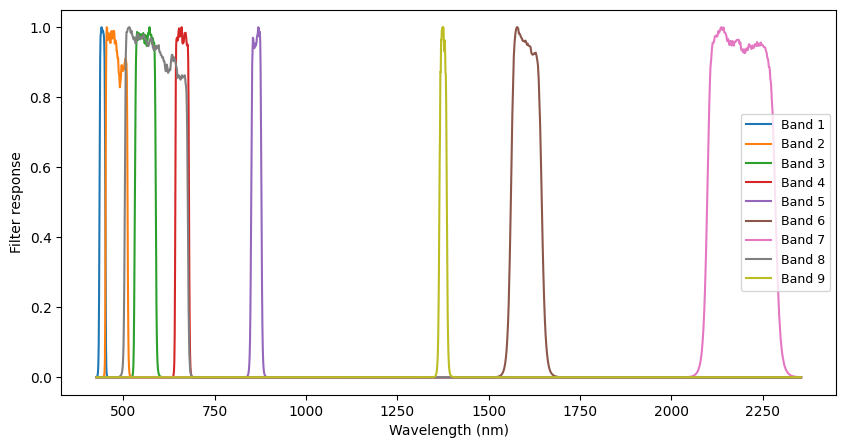

In [ ]:
# VISUALIZE CHANNELS SRF

fig, ax = plt.subplots(figsize=(10, 5))
df_fullrange_bands.plot(ax=ax, x='Wavelength (nm)')
ax.set_ylabel('Filter response')
ax.legend(loc='center right', fontsize=9)

## --

In [ ]:
# OPEN AND READ SOY BEAN STUBBLE SPECTRAL SIGNATURE DATA (CONAE)

path_spct = '/content/94_2_1.txt' # CONAE Soy Bean spectroradiometer data

df_spct = pd.read_csv(
      path_spct,
      delim_whitespace=True,
      skiprows=39, # found by iteration
      names = ['Wavelength (nm)', 'Reflectance']
  )

/tmp/ipykernel_1620/3404598555.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_spct = pd.read_csv(


In [ ]:
# GET WAVELENGTH VALUES AND REFLECTANCE DATA
wvl_data = df_spct[df_spct.columns[0]].values
reflc_data = df_spct[df_spct.columns[1]].values

Text(0.5, 0, 'Wavelength (nm)')

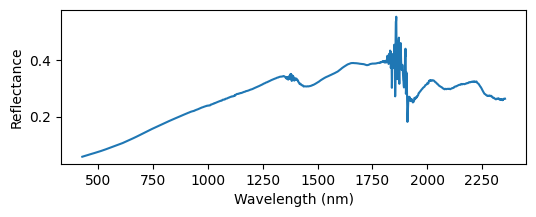

In [ ]:
# MASK ACCORDING TO DE WL RANGE, AND VISUALIZE SOY BEAN STUBBLE DATA

# Define the mask according to the predefined wl range
mask = (wvl_data >= wl_start) & (wvl_data <= wl_end)

# Mask data
wvl_data_filt = wvl_data[mask]
reflc_data_filt = reflc_data[mask]

# Plot data
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(wvl_data_filt, reflc_data_filt)
ax.set_ylabel('Reflectance')
ax.set_xlabel('Wavelength (nm)')

Text(0.5, 0, 'Wavelength (nm)')

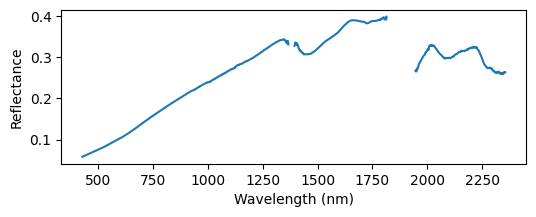

In [ ]:
# MASK ACCORDING TO DE WL RANGE, AND VISUALIZE SOY BEAN STUBBLE DATA
reflc_data_nan = reflc_data_filt.copy()

# Define wavelength value and buffer for noise removing
# NOTE: change de buffer value as necessary!
list_corrs = [(1380, 13), (1880, 65)] # (wavelength, buffer)

# Iterate to remove noise
for wvl, wvl_buffer in list_corrs:
  reflc_data_nan[(wvl_data_filt >= wvl-wvl_buffer) & (wvl_data_filt <= wvl+wvl_buffer)] = np.nan

# Plot results
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(wvl_data_filt, reflc_data_nan)
ax.set_ylabel('Reflectance')
ax.set_xlabel('Wavelength (nm)')

In [ ]:
# Unify datasets
dfFR_bandsSpct = df_fullrange_bands.copy()
dfFR_bandsSpct['Reflectance_spct'] = reflc_data_nan

dfFR_bandsSpct.head()

,Wavelength (nm),Band 1,Band 2,Band 3,Band 4,Band 5,Band 6,Band 7,Band 8,Band 9,Reflectance_spct
0,427,0.000255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058239
1,428,0.000984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058486
2,429,0.002414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058725
3,430,0.005829,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058993
4,431,0.014537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.059281


In [ ]:
# OPTIONAL: EXPORT AND DOWNLOAD UNIFIED DATASET
#dfFR_bandsSpct.to_csv('dfFR_bandsSpct.csv', index=False)

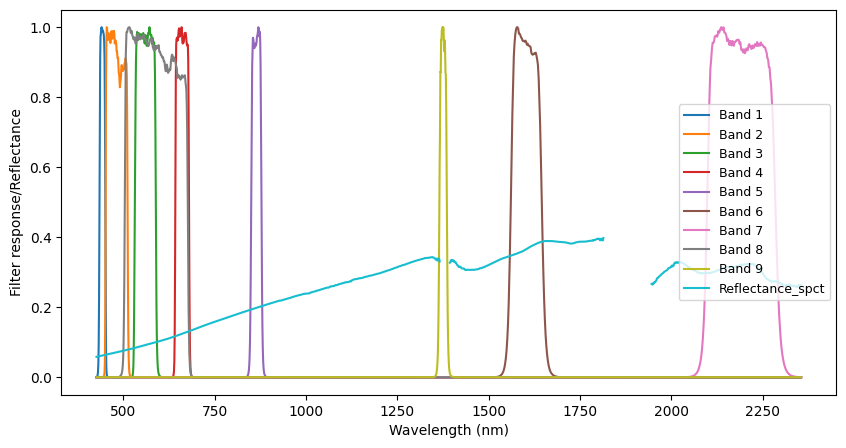

In [ ]:
# PLOT UNIFIED DATASET DATA
fig, ax = plt.subplots(figsize=(10, 5))
dfFR_bandsSpct.plot(ax=ax, x='Wavelength (nm)')
ax.set_ylabel('Filter response/Reflectance')
ax.legend(loc='center right', fontsize=9)

## --

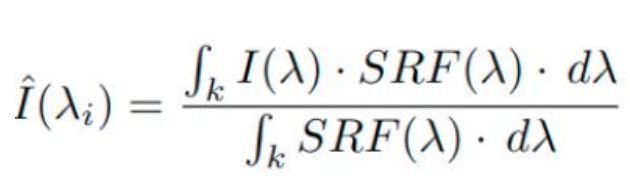

In [ ]:
# GET DATA

# Get bands name
channels_list = dfFR_bandsSpct.columns.values.tolist()[1:]
channels_list.pop(-3) # Remove pachromatic channel (see above)
#channels_list

# Store srf and i bands name separated
srf_channels = channels_list[:-1]
i_channel = channels_list[-1]

In [ ]:
# RESOLVE THE RESAMPLING INTEGRAL NUMERICALLY FOR EACH BAND AND STORE THE RESULT

list_spctRes = []

for sc in srf_channels:
    srf_c = dfFR_bandsSpct[sc].values
    i_c = dfFR_bandsSpct[i_channel].values

    mult_num = srf_c * i_c
    denm = i_c

    # mask where BOTH arrays are valid
    valid = (~np.isnan(srf_c)) & (~np.isnan(i_c))

    multIntg_num_val = np.sum(mult_num[valid])
    intg_denm_val = np.sum(denm[valid])

    i_intg = multIntg_num_val / intg_denm_val

    list_spctRes.append(i_intg)

    #print(sc, i_intg)

Text(0.5, 0, 'OLI L8 Band number')

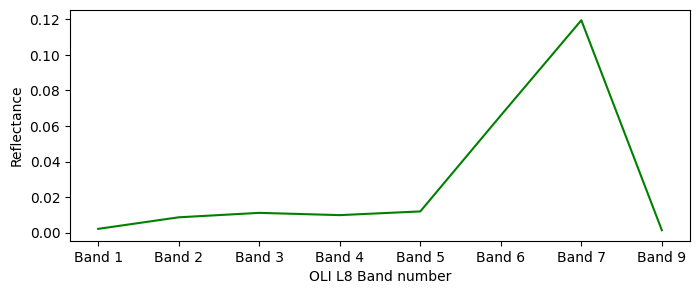

In [ ]:
# PLOT RESULTS
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(srf_channels, np.array(list_spctRes), color='green')
ax.set_ylabel('Reflectance')
ax.set_xlabel('OLI L8 Band number')